# NB03 — Functional Diversity Census

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB01, genome depot (`enigma_genome_depot_enigma`)

## Goal

Characterize the phylogenetic breadth, metabolic diversity, and ecological functional repertoire of the 123 ENIGMA growth-curve strains. Identify metabolically distinct classes expected to have different growth phenotypes. This sets the stage for feature engineering (NB05) and provides the *a priori* classification that predictions should recover.

## Key Findings

1. **123 strains span 20 taxonomic orders**, dominated by Burkholderiales (39), Pseudomonadales (27), Xanthomonadales (8), Hyphomicrobiales (7), Enterobacterales (7).
2. **7,167 unique KEGG orthologs** across the collection. Per-strain KO count ranges from 1,256 to 3,014 (median 2,121).
3. **8 metabolic guilds** identified by hierarchical clustering of KO presence/absence (Jaccard distance, Ward linkage). Guilds align with taxonomic orders but are defined by functional gene content.
4. **Genome size spans 2.6–11.4 Mb** with strong correlation to KO diversity (r > 0.9). The 7 FB-anchor strains cluster in guilds 2 (Pseudomonadales) and 3 (Burkholderiales).
5. **23 COG functional classes** profiled per strain. Guild-level COG profiles show class-specific functional enrichment.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 200)

DATA = Path('../data')
FIG = Path('../figures')


## 1. Strain collection overview

In [2]:
sc = pd.read_csv(DATA / 'strain_scalars.tsv', sep='\t')
print(f'Total strains: {len(sc)}')
print(f'Taxonomic orders: {sc.taxon_order.nunique()}')
print(f'Genome size: {sc["size"].min():,} – {sc["size"].max():,} bp')
print(f'Genes: {sc.genes.min()} – {sc.genes.max()} (median {sc.genes.median():.0f})')
print(f'Unique KOs: {sc.n_unique_kos.min()} – {sc.n_unique_kos.max()} (median {sc.n_unique_kos.median():.0f})')
print()
print('== Taxonomy (order level) ==')
sc.taxon_order.value_counts().head(10)


Total strains: 123
Taxonomic orders: 20
Genome size: 2,585,850 – 11,421,938 bp
Genes: 2494 – 10541 (median 5371)
Unique KOs: 1256 – 3014 (median 2121)

== Taxonomy (order level) ==


taxon_order
Burkholderiales     39
Pseudomonadales     27
Xanthomonadales      8
Hyphomicrobiales     7
Enterobacterales     7
Unknown              6
Bacillales           5
Caulobacterales      5
Micrococcales        4
Rhodocyclales        3
Name: count, dtype: int64

## 2. Metabolic guild clustering

In [3]:
guild_summary = sc.groupby('guild').agg(
    n_strains=('strain_id','count'),
    dominant_order=('taxon_order', lambda x: x.mode().iloc[0] if len(x.mode()) else 'mixed'),
    mean_genome_Mb=('size', lambda x: round(x.mean()/1e6, 2)),
    mean_genes=('genes','mean'),
    mean_kos=('n_unique_kos','mean'),
).round(0)
guild_summary


,n_strains,dominant_order,mean_genome_Mb,mean_genes,mean_kos
guild,,,,,
1,7,Enterobacterales,5.0,4672.0,2788.0
2,27,Pseudomonadales,7.0,6291.0,2658.0
3,46,Burkholderiales,6.0,5538.0,2128.0
4,5,Bacillales,5.0,4730.0,1847.0
5,7,Micrococcales,4.0,4157.0,1544.0
6,17,Hyphomicrobiales,5.0,5195.0,1872.0
7,6,Flavobacteriales,5.0,4452.0,1372.0
8,8,Xanthomonadales,4.0,4295.0,1632.0


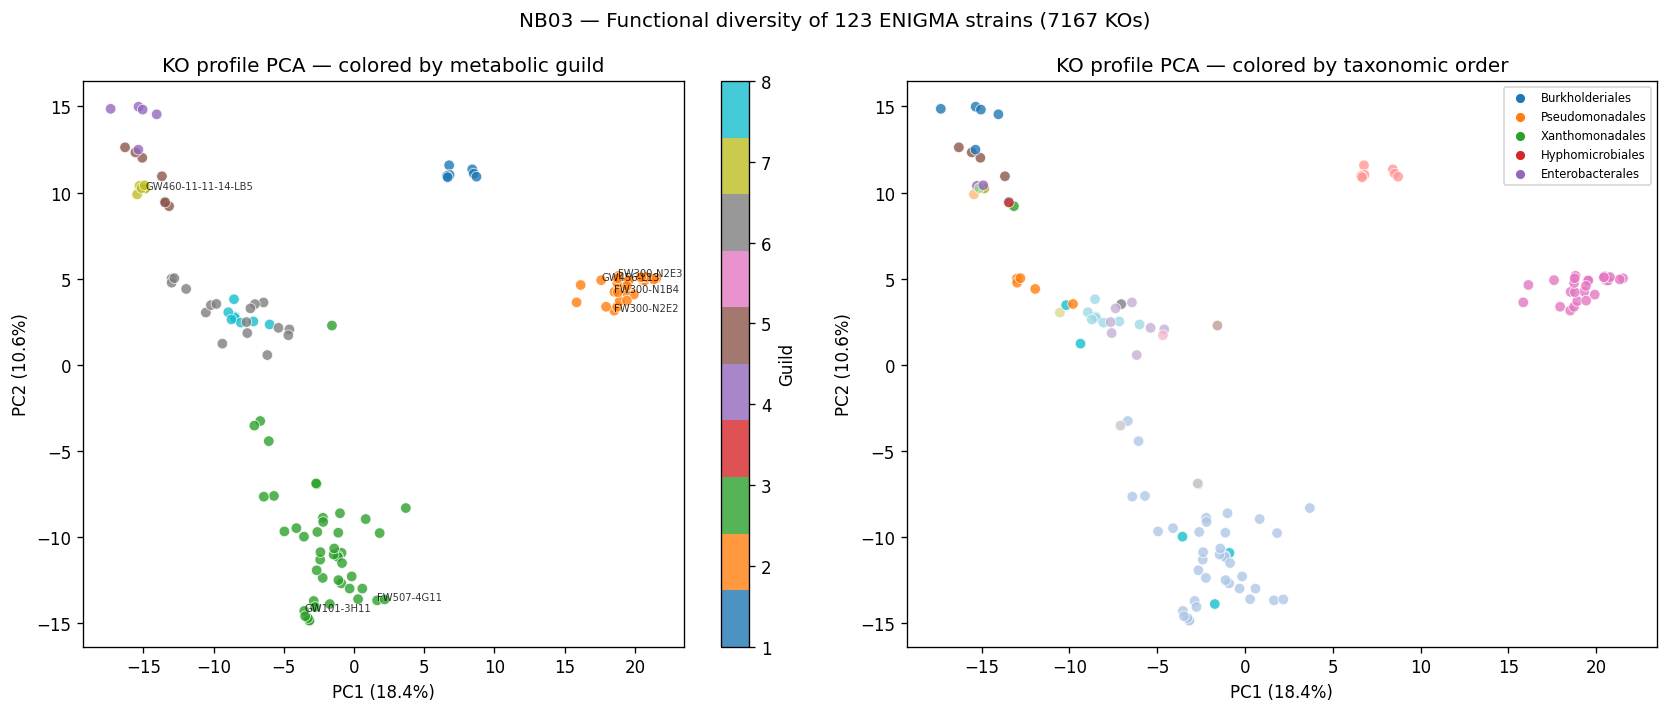

In [4]:
from IPython.display import Image
Image(filename=str(FIG / 'NB03_ko_pca_guilds.png'))


### Guild interpretation

| Guild | n | Dominant order | Avg KOs | Interpretation |
|---|---|---|---|---|
| 1 | 7 | Enterobacterales | 2788 | Generalist enteric bacteria — broad metabolic repertoire |
| 2 | 27 | Pseudomonadales | 2658 | Versatile Pseudomonads — the FB-anchor guild |
| 3 | 46 | Burkholderiales | 2128 | Diverse Burkholderiaceae/Comamonadaceae |
| 4 | 5 | Bacillales | 1847 | Gram-positive spore formers |
| 5 | 7 | Micrococcales | 1544 | Actinobacterial degraders |
| 6 | 17 | Hyphomicrobiales | 1872 | Rhizobiales (Agrobacterium, Methylobacterium) |
| 7 | 6 | Flavobacteriales | 1372 | Bacteroidetes — fewest KOs, likely specialists |
| 8 | 8 | Xanthomonadales | 1632 | Rhodanobacter, Dyella — adapted to contaminated environments |

The Pseudomonas guild (2) is the best-sampled: it contains 5 of 7 FB-anchor strains and has the broadest growth curve coverage. Guild 7 (Flavobacteriales) has the fewest KOs and may show the most distinct growth phenotype profile.


## 3. COG functional profiles by guild

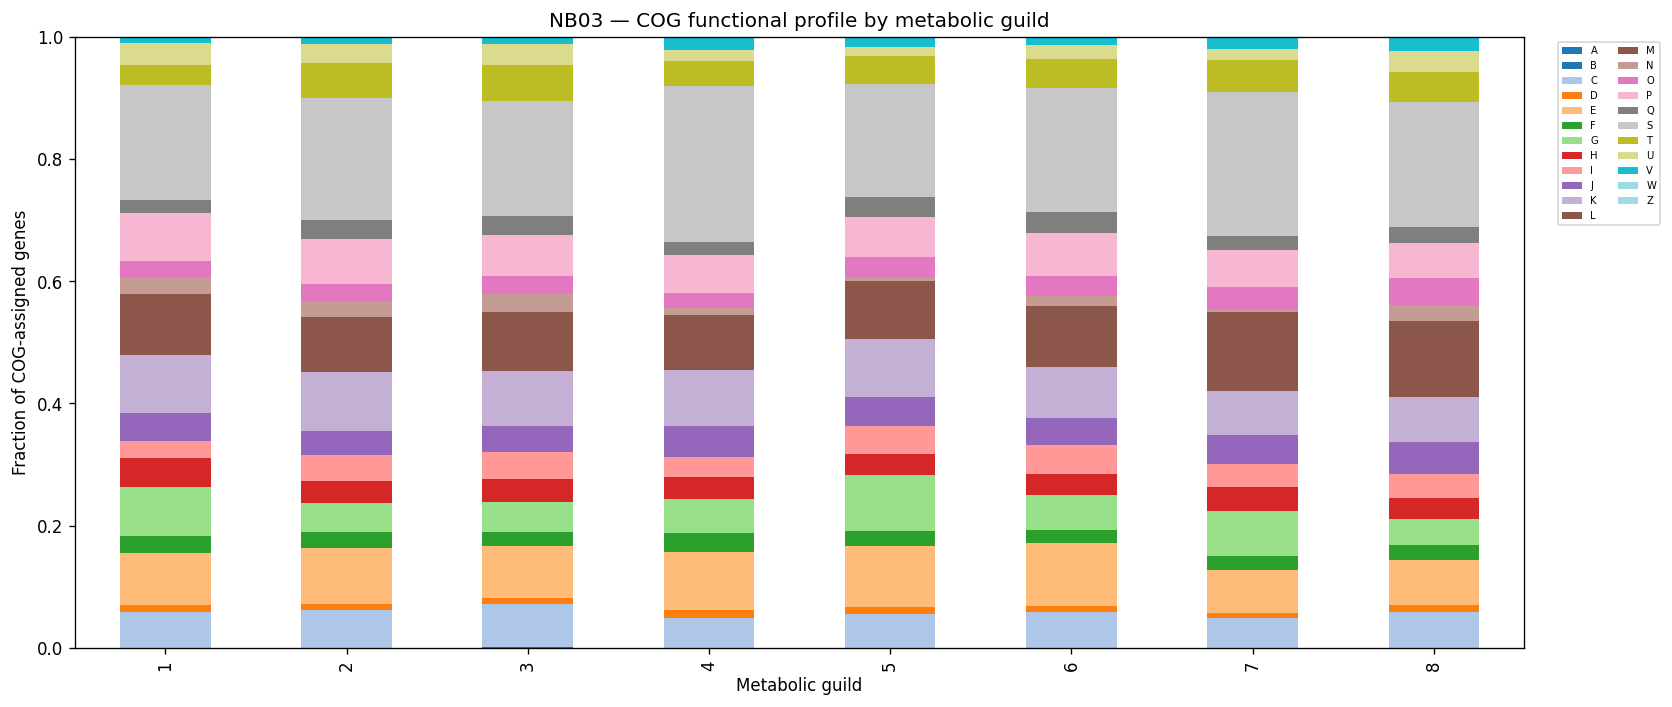

In [5]:
Image(filename=str(FIG / 'NB03_cog_by_guild.png'))


In [6]:
cog = pd.read_csv(DATA / 'cog_matrix.tsv', sep='\t', index_col=0)
cog_desc = pd.read_csv(DATA / 'cog_class_descriptions.tsv', sep='\t')
print(f'COG classes: {len(cog_desc)}')
cog_desc


COG classes: 23


,cog_id,cog_desc
0,A,RNA processing and modification
1,B,Chromatin structure and dynamics
2,C,Energy production and conversion
3,D,"Cell cycle control, cell division, chromosome ..."
4,E,Amino acid transport and metabolism
5,F,Nucleotide transport and metabolism
6,G,Carbohydrate transport and metabolism
7,H,Coenzyme transport and metabolism
8,I,Lipid transport and metabolism
9,J,"Translation, ribosomal structure and biogenesis"


## 4. Genome scale vs functional diversity

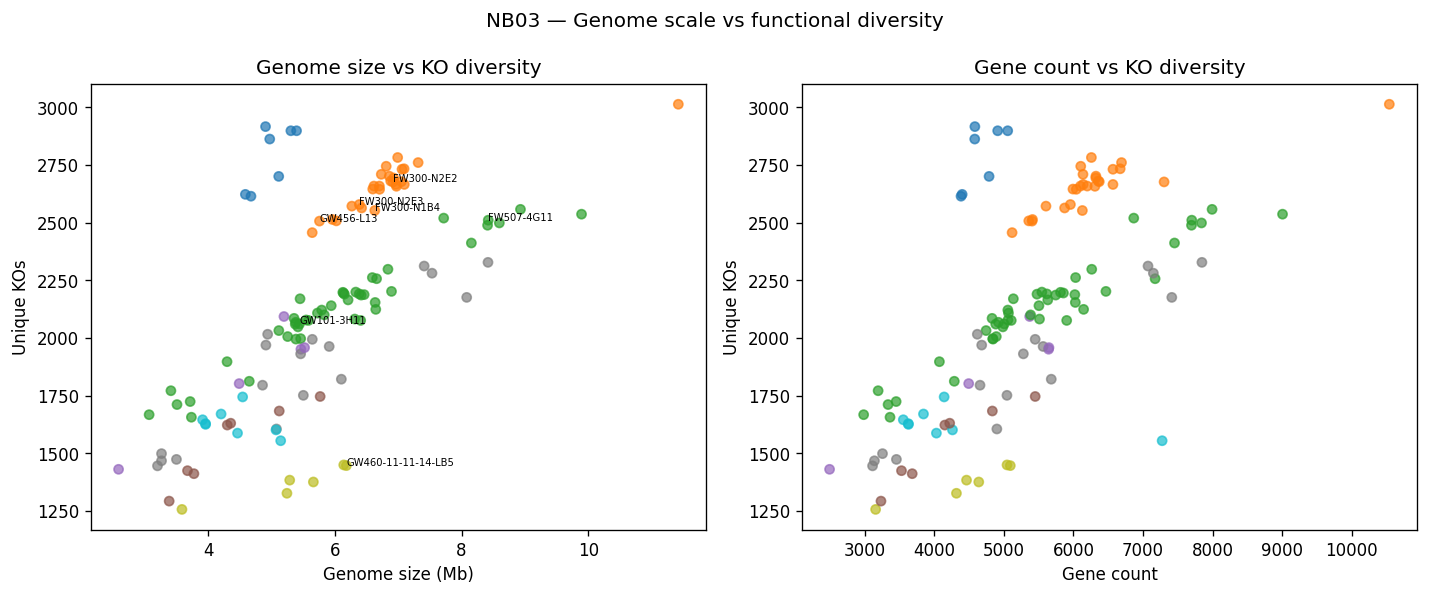

In [7]:
Image(filename=str(FIG / 'NB03_genome_vs_ko.png'))


## 5. FB anchor strains in context

In [8]:
FB_ANCHORS = ['FW300-N1B4','FW300-N2E2','FW300-N2E3','GW456-L13','GW460-11-11-14-LB5','GW101-3H11','FW507-4G11']
sc[sc.strain_id.isin(FB_ANCHORS)][['strain_id','taxon_name','taxon_order','guild','size','genes','n_unique_kos']]


,strain_id,taxon_name,taxon_order,guild,size,genes,n_unique_kos
9,FW300-N1B4,Pseudomonas sp. FW300-N1B4,Pseudomonadales,2,6630486,6128,2553
11,FW300-N2E2,Pseudomonas sp. FW300-N2E2,Pseudomonadales,2,6916500,7303,2677
12,FW300-N2E3,Pseudomonas sp. FW300-N2E3,Pseudomonadales,2,6386303,5956,2579
29,FW507-4G11,Cupriavidus basilensis,Burkholderiales,3,8421443,7701,2511
35,GW101-3H11,Acidovorax sp. GW101-3H11,Burkholderiales,3,5442520,5005,2061
42,GW456-L13,Pseudomonas fluorescens,Pseudomonadales,2,5757432,5405,2507
50,GW460-11-11-14-LB5,Sphingobacteriaceae bacterium GW460-11-11-14-LB5,Sphingobacteriales,7,6182066,5092,1446


## 6. What this enables

- **NB05 (feature engineering)**: The KO matrix (123 × 7,167) is the primary genome feature set. COG class counts (123 × 23) are the bulk functional summary. Guild assignments provide a categorical feature and a basis for stratified CV.
- **NB06 (variance partitioning)**: Guild membership can be tested as a random effect alongside GTDB taxonomy — do guilds capture growth variance beyond what taxonomy explains?
- **NB07 (modeling)**: Expect guild 2 (Pseudomonas) and guild 3 (Burkholderiales) to be best-predicted (most training data). Guild 7 (Flavobacteriales, fewest KOs) is the hardest test case for out-of-distribution generalization.
- **NB04 (biogeography)**: Guild assignments provide the biological interpretation layer for environmental distributions — are certain guilds enriched in contaminated vs. background wells?

## Limitations

- **Guild count (k=8) is heuristic**. Silhouette analysis could refine this, but for 123 strains across 20 orders, 8 guilds gives reasonable granularity without over-splitting.
- **KO-only clustering**: Guilds are defined by KEGG ortholog presence, which captures metabolic potential but misses regulatory differences, mobile element load, and resistance gene repertoire. These could define sub-guilds within the current clusters.
- **No pangenome outlier analysis yet**: Identifying strains with unusual gene content relative to their clade requires the BERDL pangenome linkage (32 strains only). Deferred to NB05 feature engineering.
